In [1]:
#importing basic libarires

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
df=pd.read_csv('Dataset/phishing_site_urls.csv')

In [3]:
df.head

<bound method NDFrame.head of                                                       URL Label
0       nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad
1       www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad
2       serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad
3       mail.printakid.com/www.online.americanexpress....   bad
4       thewhiskeydregs.com/wp-content/themes/widescre...   bad
...                                                   ...   ...
549341                                    23.227.196.215/   bad
549342                                 apple-checker.org/   bad
549343                                  apple-iclods.org/   bad
549344                                 apple-uptoday.org/   bad
549345                                  apple-search.info   bad

[549346 rows x 2 columns]>

In [4]:
df.shape

(549346, 2)

In [5]:
df.info

<bound method DataFrame.info of                                                       URL Label
0       nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad
1       www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad
2       serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad
3       mail.printakid.com/www.online.americanexpress....   bad
4       thewhiskeydregs.com/wp-content/themes/widescre...   bad
...                                                   ...   ...
549341                                    23.227.196.215/   bad
549342                                 apple-checker.org/   bad
549343                                  apple-iclods.org/   bad
549344                                 apple-uptoday.org/   bad
549345                                  apple-search.info   bad

[549346 rows x 2 columns]>

In [6]:
df.isnull().sum()

URL      0
Label    0
dtype: int64

In [7]:
df.Label.value_counts()

Label
good    392924
bad     156422
Name: count, dtype: int64

In [8]:
from nltk.tokenize import RegexpTokenizer

In [9]:
tokenizer=RegexpTokenizer(r'[A-Za-z]+')

In [10]:
df.URL[0]

'nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526'

In [11]:
tokenizer.tokenize(df.URL[0])

['nobell',
 'it',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'login',
 'SkyPe',
 'com',
 'en',
 'cgi',
 'bin',
 'verification',
 'login',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'index',
 'php',
 'cmd',
 'profile',
 'ach',
 'outdated',
 'page',
 'tmpl',
 'p',
 'gen',
 'failed',
 'to',
 'load',
 'nav',
 'login',
 'access']

In [12]:
df['text_tokenized']=df.URL.map(lambda t:tokenizer.tokenize(t))

In [13]:
df.head


<bound method NDFrame.head of                                                       URL Label  \
0       nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad   
1       www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad   
2       serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad   
3       mail.printakid.com/www.online.americanexpress....   bad   
4       thewhiskeydregs.com/wp-content/themes/widescre...   bad   
...                                                   ...   ...   
549341                                    23.227.196.215/   bad   
549342                                 apple-checker.org/   bad   
549343                                  apple-iclods.org/   bad   
549344                                 apple-uptoday.org/   bad   
549345                                  apple-search.info   bad   

                                           text_tokenized  
0       [nobell, it, ffb, d, dca, cce, f, login, SkyPe...  
1       [www, dghjdgf, com, paypal, co, uk, c

In [14]:
from nltk.stem.snowball import SnowballStemmer

# Assistant
The error occurs because there's a typo in the import statement. The correct name of the stemmer is "SnowballStemmer" (with "w"), not "SnomballStemmer" (with "m").

Would you like me to provide the corrected code?

In [15]:
stemmer=SnowballStemmer('english')

In [16]:
# Check if the column exists with the correct spelling
# Option 1: If the column name is misspelled and should be something else
# Replace 'text_tokenized' with the actual column name that exists in your DataFrame
df['text_tokenized'].map(lambda l:[stemmer])



0         [<nltk.stem.snowball.SnowballStemmer object at...
1         [<nltk.stem.snowball.SnowballStemmer object at...
2         [<nltk.stem.snowball.SnowballStemmer object at...
3         [<nltk.stem.snowball.SnowballStemmer object at...
4         [<nltk.stem.snowball.SnowballStemmer object at...
                                ...                        
549341    [<nltk.stem.snowball.SnowballStemmer object at...
549342    [<nltk.stem.snowball.SnowballStemmer object at...
549343    [<nltk.stem.snowball.SnowballStemmer object at...
549344    [<nltk.stem.snowball.SnowballStemmer object at...
549345    [<nltk.stem.snowball.SnowballStemmer object at...
Name: text_tokenized, Length: 549346, dtype: object

In [17]:
df['text_stemmed']=df.text_tokenized.map(lambda l:[stemmer.stem(word) for word in l])

In [18]:
df.head()

,URL,Label,text_tokenized,text_stemmed
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide..."


In [19]:
df['text']=df['text_stemmed'].map(lambda l:' '.join(l))

In [20]:
df.head


<bound method NDFrame.head of                                                       URL Label  \
0       nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad   
1       www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad   
2       serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad   
3       mail.printakid.com/www.online.americanexpress....   bad   
4       thewhiskeydregs.com/wp-content/themes/widescre...   bad   
...                                                   ...   ...   
549341                                    23.227.196.215/   bad   
549342                                 apple-checker.org/   bad   
549343                                  apple-iclods.org/   bad   
549344                                 apple-uptoday.org/   bad   
549345                                  apple-search.info   bad   

                                           text_tokenized  \
0       [nobell, it, ffb, d, dca, cce, f, login, SkyPe...   
1       [www, dghjdgf, com, paypal, co, uk,

In [21]:
good_sites = df[df.Label == 'good']
bad_sites = df[df.Label == 'bad']

In [22]:
good_sites.head()


,URL,Label,text_tokenized,text_stemmed,text
18231,esxcc.com/js/index.htm?us.battle.net/noghn/en/...,good,"[esxcc, com, js, index, htm, us, battle, net, ...","[esxcc, com, js, index, htm, us, battl, net, n...",esxcc com js index htm us battl net noghn en r...
18232,wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË\nÓ6...,good,"[www, eira, nvinip, ncH, wV, yDaH, yE, u, rT, ...","[www, eira, nvinip, nch, wv, ydah, ye, u, rt, ...",www eira nvinip nch wv ydah ye u rt u g m i xz...
18233,'www.institutocgr.coo/web/media/syqvem/dk-óij...,good,"[www, institutocgr, coo, web, media, syqvem, d...","[www, institutocgr, coo, web, media, syqvem, d...",www institutocgr coo web media syqvem dk ij r ...
18234,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,good,"[Y, ko, D, l, qt]","[y, ko, d, l, qt]",y ko d l qt
18236,ruta89fm.com/images/AS@Vies/1i75cf7b16vc<Fd16...,good,"[ruta, fm, com, images, AS, Vies, i, cf, b, vc...","[ruta, fm, com, imag, as, vie, i, cf, b, vc, f...",ruta fm com imag as vie i cf b vc f d b g sd v...


In [23]:
def plot_wordcloud(text, mask=None, max_words=400, max_font_size=120, figure_size=(24.0,16.0),
                  title=None, title_size=40, image_color=False):
    # Fixed 'Nome' to 'None' and fixed parameter syntax
    
    stopwords = set(STOPWORDS)
    more_stopwords = ('com', 'http')  # Fixed unclosed string literal
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(background_color='white',  # Fixed 'colors' to 'color'
                         stopwords=stopwords,
                         max_words=max_words,
                         max_font_size=max_font_size,
                         random_state=42,
                         mask=mask)  # Fixed spacing
    wordcloud.generate(text)

    plt.figure(figsize=figure_size)  # Fixed spacing
    if image_color:
        image_colors = ImageColorGenerator(mask)  # Fixed typo in Generator
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear")  # Fixed typo in wordcloud
        plt.title(title, fontdict={'size': title_size,  # Changed [ to { for dict
                                  'verticalalignment': 'bottom'})
    else:
        plt.imshow(wordcloud)
        plt.title(title, fontdict={'size': title_size, 'color': 'green',  # Changed [ to { for dict
                                  'verticalalignment': 'bottom'})

    plt.axis('off')
    plt.tight_layout()

In [24]:
all_text = ' '.join(good_sites['text'].tolist())

In [25]:
from wordcloud import WordCloud


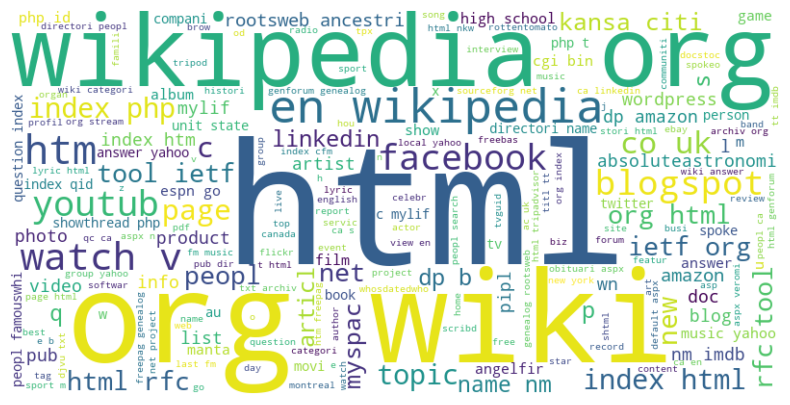

In [26]:
# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [27]:
df.head

<bound method NDFrame.head of                                                       URL Label  \
0       nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad   
1       www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad   
2       serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad   
3       mail.printakid.com/www.online.americanexpress....   bad   
4       thewhiskeydregs.com/wp-content/themes/widescre...   bad   
...                                                   ...   ...   
549341                                    23.227.196.215/   bad   
549342                                 apple-checker.org/   bad   
549343                                  apple-iclods.org/   bad   
549344                                 apple-uptoday.org/   bad   
549345                                  apple-search.info   bad   

                                           text_tokenized  \
0       [nobell, it, ffb, d, dca, cce, f, login, SkyPe...   
1       [www, dghjdgf, com, paypal, co, uk,

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

In [29]:
cv = CountVectorizer()

In [30]:
features = cv.fit_transform(df.text)

In [31]:
features[:5].toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5, 350837))

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
feature = df.drop('Label', axis=1)  # This removes the Label column and keeps all other columns as features

# Now use the defined feature variable in train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, df.Label)

In [34]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2757016 stored elements and shape (412009, 350837)>

Model Training

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split  # Added import for train_test_split

model_1 = LogisticRegression()

x_train, x_test, y_train, y_test = train_test_split(features, df.Label, test_size=0.2, random_state=42) 

model_1.fit(x_train, y_train)

model_1.score(x_test, y_test)

c:\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9642941658323473

In [36]:
model_1.score(x_train, y_train)

0.9781967615979029

In [37]:
from sklearn.metrics import classification_report

In [38]:
print('\nCLASSIFICATION REPORT\n')
print(classification_report(model_1.predict(x_test), y_test,
target_names =['Bad','Good']))


CLASSIFICATION REPORT

              precision    recall  f1-score   support

         Bad       0.90      0.97      0.94     29169
        Good       0.99      0.96      0.98     80701

    accuracy                           0.96    109870
   macro avg       0.95      0.97      0.96    109870
weighted avg       0.97      0.96      0.96    109870



In [40]:
from sklearn.metrics import confusion_matrix

con_mat = pd.DataFrame(confusion_matrix(model_1.predict(x_test), y_test),
columns = ['Predicted:Bad', 'Predicted:Good'],
index = ['Actual:Bad', 'Actual:Good'])

In [41]:
from sklearn.metrics import confusion_matrix

In [42]:
con_mat = pd.DataFrame(confusion_matrix(model_1.predict(x_test), y_test),
columns = ['Predicted:Bad', 'Predicted:Good'],
index = ['Actual:Bad', 'Actual:Good'])

In [43]:
import seaborn as sns


CONFUSION MATRIX


<Axes: >

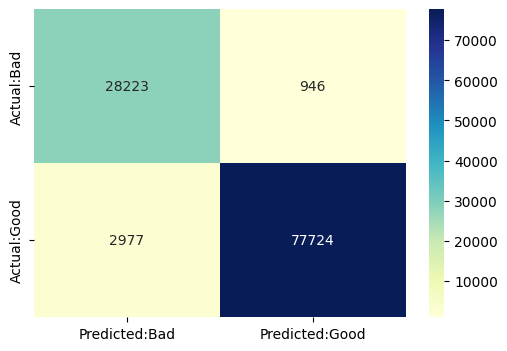

In [45]:
print('\nCONFUSION MATRIX')
plt.figure(figsize= (6,4))
sns.heatmap(con_mat, annot = True,fmt='d',cmap="YlGnBu")

In [46]:
from sklearn.naive_bayes import MultinomialNB

In [47]:
mnb = MultinomialNB()

In [48]:
mnb.fit(x_train,y_train)

MultinomialNB()

In [49]:
mnb.score(x_test, y_test)

0.958359879858014

In [50]:
# Logistic Regression
# Decision Tree Classifier
# Random Forest Classifier
# Gradient Boostiing Classifier
# AdaBoost Classifier
# Support Vector Classifier (RBF Kernel)
# K-Neighbors Classifier
# Naive Bayes (Gaussian)
# MLP Classifier (Neural Network)

Save Model

In [51]:
import pickle
pickle.dump(model_1, open('phishing.pkl','wb'))

In [52]:
pickle.dump(mnb, open('phishing.pkl','wb'))

In [53]:
pickle.dump(cv, open('vectorizer.pkl','wb'))


* Bad links => this are phishing sites

yeniik.com.tr/wp-admin/js/login.alibaba.com/login.jsp.php
fazan-pacir.rs/temp/libraries/ipad
www.tubemoviez.exe
svision-online.de/mgfi/administrator/components/com_babackup/classes/fx29id1.txt

* Good links => this are not phishing sites

www.youtube.com/
youtube.com/watch?v=qI0TQJI3vdU
www.retailhellunderground.com/
restorevisioncenters.com/html/technology.html

In [54]:
predict_bad = ['yeniik.com.tr/wp-admin/js/login.alibaba.com/login.jsp.php','fazan-pacir.rs/temp/libraries/ipad','tubemoviez.exe','svision-online.de/mgfi/administrator/components/com_babackup/classes/fx29id1.txt']
predict_good = ['youtube.com/','youtube.com/watch?v=qI0TQJI3vdU','retailhellunderground.com/','restorevisioncenters.com/html/technology.html']

In [55]:
predict_good = cv.transform(predict_good)

In [56]:
predict_bad = cv.transform(predict_bad)

In [57]:
model_1.predict(predict_good)

array(['good', 'good', 'good', 'good'], dtype=object)

In [58]:
model_1.predict(predict_bad)

array(['bad', 'bad', 'bad', 'bad'], dtype=object)

In [59]:
mnb.predict(predict_good)

array(['good', 'good', 'good', 'good'], dtype='<U4')